-----------------------------------------------
Latest data collection 18 feb

Single taps each 1 - 2 seconds

continuous swipe 0.5 Hz - 3 Hz

Hold 1 sec - 2 sec and 1 sec interval between holds

# Do not use RUN ALL before changing the files name

# Libraries

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks
import numpy as np
import seaborn as sns


# Swipe

In [2]:
# # # Load the CSV file into a DataFrame
# # Change the file if needed here

df_swipe = pd.read_csv('Data_online_18_FEB_LA_SWIPE.csv')



In [3]:
# # Filter rows where Temps is between 5 and 40

# # Why 5 I skipped first 5 seconds because before I did not add a start timer in the data collection.
# # Thus, when the data collection starts the signals always starts a high value and collects noise


df_swipe = df_swipe[(df_swipe['Temps'] >= 5) & (df_swipe['Temps'] <= 60)].copy()


# # Adding the label manually for each row
# # Add a new column with value 'swipe'
df_swipe.loc[:, 'f11'] = 'swipe'

print(df_swipe)


         Temps     tribo_f1     tribo_f2     tribo_f3    tribo_f4    tribo_f5  \
9     5.113730   867.252227   263.196651   272.388167  452.402315  322.023142   
10    5.231078   870.318565   258.006620   247.948810  235.857207   75.350879   
11    5.347617   874.784858   354.816820   267.668990  109.003480  249.019891   
12    5.463625   879.805381   397.659676   290.486560  194.864559  333.900313   
13    5.578878   845.586585   417.446937   213.452927  315.328905  252.233790   
..         ...          ...          ...          ...         ...         ...   
481  59.453187  1130.841744   988.073763  3295.227054  806.002992  512.907765   
482  59.567205  1442.304931  1283.702634  3078.216790  576.822297  357.186181   
483  59.680485  2097.802696  1765.245890  2415.957388  364.008016  381.236070   
484  59.794110  1830.218817  1830.397877  2369.340622  347.378168  670.824278   
485  59.908248  1789.448184  1889.133928  2319.080305  440.739808  760.960431   

        tribo_f6     tribo_

# HOLD

In [4]:
df_hold = pd.read_csv('Data_online_18_FEB_LA_HOLD.csv')

print(df_hold)

        tribo_f1     tribo_f2     tribo_f3     tribo_f4     tribo_f5  \
0    1129.757119  1365.087440  1017.997836   407.378574   454.781472   
1    1129.757119  1365.087440  1017.997836   407.378574   454.781472   
2    1128.150944  1425.846666   938.025021   384.887032   393.306914   
3    1123.154614  1462.515173   776.271056   309.784894   537.464644   
4    1129.544242  1472.718491   550.244972   247.419603   775.926353   
..           ...          ...          ...          ...          ...   
483  4358.204819  2523.144315   932.608385  1239.253225  1408.425626   
484  4412.560107  2498.734382   878.419902  1261.224540  1387.513790   
485  4031.064352  2575.474620  1222.780395  1398.370372  1268.561572   
486  3412.879151  2631.315813  1721.383845  2007.319733   824.021752   
487  3013.436550  2625.167050  2000.803066  2456.327596   401.642601   

        tribo_f6    tribo_f7     tribo_f8    tribo_f9    tribo_f10  ...  \
0     158.967965  868.733072   120.699708  134.679157   547.

In [5]:
# Filter rows where Temps is between 5 and 40
df_hold = df_hold[(df_hold['Temps'] >= 5) & (df_hold['Temps'] <= 50)].copy()

# Add a new column with value 'hold'
df_hold.loc[:, 'f11'] = 'hold'

print(df_hold)

        tribo_f1     tribo_f2     tribo_f3     tribo_f4     tribo_f5  \
10   1529.820106   430.818371  1096.549840   284.792818   966.501468   
11   1536.728737   394.704322  1094.876257   272.541093   992.111843   
12   1958.361096  1532.136076  2037.074299  1366.366648  1721.674429   
13   2609.202051  2229.543616  2785.822748  1957.232521  2396.899578   
14   2959.992738  2524.998638  3077.268561  2117.057602  2544.503148   
..           ...          ...          ...          ...          ...   
455  4225.759131  2172.186645  1683.296831  1265.944749  1155.195971   
456  4120.202246  2550.213954  1875.361260   632.323323  1536.146438   
457  4120.681825  2547.358882  1873.403316   637.391680  1532.120736   
458  4119.137599  2542.086537  1867.915964   636.954253  1529.802997   
459  4123.694266  2555.104294  1880.679120   641.102129  1530.764584   

        tribo_f6     tribo_f7     tribo_f8     tribo_f9    tribo_f10  ...  \
10    477.498095   776.920537   298.512311   107.808134   

# TAP

In [6]:
df_tap = pd.read_csv('Data_online_18_FEB_LA_TAP.csv')

In [7]:
# Filter rows where Temps is between 5 and 40
df_tap = df_tap[(df_tap['Temps'] >= 5) & (df_tap['Temps'] <= 60)].copy()

# Add a new column with value 'tap'
df_tap.loc[:, 'f11'] = 'tap'

print(df_tap)


        tribo_f1     tribo_f2     tribo_f3     tribo_f4     tribo_f5  \
10   4219.364763  2338.453333   978.967877  1436.880556   742.885021   
11   4626.683334  2006.937437  1148.388874  1401.873514   344.541240   
12   4626.683334  2006.937437  1148.388874  1401.873514   344.541240   
13   4959.660545  1343.084944   995.747930   707.256303  1073.970772   
14   5076.422158   997.757334   891.015380   376.559998  1273.523054   
..           ...          ...          ...          ...          ...   
432  3935.000189   763.543024   899.369087  2296.791180  1327.655423   
433  4052.703908   880.237662   793.754153  2175.291676  1445.435064   
434  4269.127058  1134.397518   545.083835  1930.947053  1555.828734   
435  4408.824540  1310.112120   370.152413  1829.160963  1520.826193   
436  4553.107801  1495.504373   260.751627  1853.241411  1360.703063   

        tribo_f6     tribo_f7     tribo_f8     tribo_f9   tribo_f10  ...  \
10    873.972072   139.308891    52.024107   569.428573  42

# NOTHING

In [8]:
df_nothing = pd.read_csv('Data_online_18_FEB_LA_NOTHING.csv')

In [9]:
# Filter rows where Temps is between 5 and 40
df_nothing = df_nothing[(df_nothing['Temps'] >= 5) & (df_nothing['Temps'] <= 50)].copy()

# Add a new column with value 'Nothing'
df_nothing.loc[:, 'f11'] = 'Nothing'

print(df_nothing)


       tribo_f1    tribo_f2    tribo_f3    tribo_f4    tribo_f5    tribo_f6  \
10   144.028107  102.640279  285.551290  494.768741  289.147778  410.772823   
11   207.426028   97.969906  295.446200  425.489685  288.397427  478.811571   
12   131.822330   78.356566  187.314426  475.633756  165.335090  540.091996   
13   159.635746  154.938448   80.995354  474.778951  131.434855  650.401234   
14   139.212837  134.255517  113.481656  490.926031  109.869302  631.395572   
..          ...         ...         ...         ...         ...         ...   
454  116.087968  111.733663   57.869408   61.026704   39.699280  104.218009   
455  121.138382  120.754262   67.297281   52.896561   45.717414   96.237373   
456  130.210003  135.739430   82.373861   50.433909   50.260028   97.231132   
457  122.082693  121.552012   73.591482   38.506413   66.795224   72.058871   
458  123.828177  124.779498   69.205695   53.605702   47.128794   90.923316   

       tribo_f7    tribo_f8    tribo_f9   tribo_f10

# MERGE ALL

In [10]:
# Drop 'Temps' column from each DataFrame
df_hold.drop('Temps', axis=1, inplace=True)
df_swipe.drop('Temps', axis=1, inplace=True)
df_nothing.drop('Temps', axis=1, inplace=True)
df_tap.drop('Temps', axis=1, inplace=True)


In [11]:

# Combine all DataFrames vertically (row-wise)
df_features = pd.concat([df_swipe, df_nothing, df_tap
, df_hold
], ignore_index=True)


print(df_features)


         tribo_f1     tribo_f2     tribo_f3     tribo_f4     tribo_f5  \
0      867.252227   263.196651   272.388167   452.402315   322.023142   
1      870.318565   258.006620   247.948810   235.857207    75.350879   
2      874.784858   354.816820   267.668990   109.003480   249.019891   
3      879.805381   397.659676   290.486560   194.864559   333.900313   
4      845.586585   417.446937   213.452927   315.328905   252.233790   
...           ...          ...          ...          ...          ...   
1798  4225.759131  2172.186645  1683.296831  1265.944749  1155.195971   
1799  4120.202246  2550.213954  1875.361260   632.323323  1536.146438   
1800  4120.681825  2547.358882  1873.403316   637.391680  1532.120736   
1801  4119.137599  2542.086537  1867.915964   636.954253  1529.802997   
1802  4123.694266  2555.104294  1880.679120   641.102129  1530.764584   

         tribo_f6     tribo_f7     tribo_f8     tribo_f9   tribo_f10  ...  \
0      324.958727   365.609356   200.868398   

In [13]:
df_features

,tribo_f1,tribo_f2,tribo_f3,tribo_f4,tribo_f5,tribo_f6,tribo_f7,tribo_f8,tribo_f9,tribo_f10,...,diff_tribo_f7,diff_tribo_f8,diff_tribo_f9,diff_tribo_f10,tribo_feature1,tribo_feature2,tribo_feature3,tribo_feature4,tribo_feature5,f11
0,867.252227,263.196651,272.388167,452.402315,322.023142,324.958727,365.609356,200.868398,454.482588,213.067737,...,417.162051,260.115776,609.214174,291.044073,121.333333,4669,97.350988,5841.001490,1709.695464,swipe
1,870.318565,258.006620,247.948810,235.857207,75.350879,331.133209,171.355036,186.407984,417.592170,349.351199,...,324.196008,253.565383,505.647934,399.990542,120.404167,4395,117.730044,5621.141421,1850.101180,swipe
2,874.784858,354.816820,267.668990,109.003480,249.019891,94.387417,405.514888,313.109875,375.175661,227.984116,...,338.878594,263.669117,517.071073,365.003906,118.700000,4116,108.837169,5486.317568,1798.000155,swipe
3,879.805381,397.659676,290.486560,194.864559,333.900313,56.434316,452.611950,267.891357,491.976927,164.770298,...,469.317481,331.351526,627.899056,217.523694,121.145833,4400,124.745743,6142.964445,2058.335997,swipe
4,845.586585,417.446937,213.452927,315.328905,252.233790,228.802143,283.898296,318.642899,304.931261,245.371152,...,403.128487,290.847509,491.730296,359.466200,123.825000,4204,146.181959,5765.756401,2221.161785,swipe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1798,4225.759131,2172.186645,1683.296831,1265.944749,1155.195971,2292.036698,595.644339,1520.280126,1437.218214,291.929429,...,1251.211196,1393.017903,1805.083148,672.816906,258.285714,13363,293.124614,11976.533541,4291.693997,hold
1799,4120.202246,2550.213954,1875.361260,632.323323,1536.146438,1664.469806,1104.947896,904.126066,897.471761,421.960067,...,1262.297841,1021.001508,773.311141,840.990548,202.285714,13986,226.472491,10990.367343,3276.520025,hold
1800,4120.681825,2547.358882,1873.403316,637.391680,1532.120736,1670.576677,1098.500379,911.790729,903.122377,411.674303,...,1148.972303,1070.759959,1172.746405,583.214544,183.982143,13986,192.974006,11327.869636,3674.182127,hold
1801,4119.137599,2542.086537,1867.915964,636.954253,1529.802997,1667.005391,1103.091951,904.206393,897.213802,422.981548,...,1153.444548,1062.637525,1166.269849,597.795670,183.982143,13986,240.380213,11292.480659,3657.621575,hold


# Here I save the dataframe, so that I can just load it again if I need.

In [62]:
# # # # # # # # # Load the CSV file into a DataFrame
# # # # # # 
# df_features = pd.read_csv('df_features_4class_ONLINE_DATA_feb18_RA.csv')



# # # # # # # # # # # # Save df_features as a CSV file
# df_features.to_csv('df_features_4class_ONLINE_DATA_feb18_LA.csv', index=False)


# PART 2 Data Process + Machine Learning

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


# Drop column target Y/ Dropping the label Y for X

In [14]:
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.metrics import classification_report, accuracy_score


# Select features (X) and target (y)
X = df_features.drop(columns=['f11'
#,'Temps'

])
y = df_features['f11']


In [15]:
from sklearn.model_selection import train_test_split

# Stratified split to maintain the proportion of each class in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(y_train.value_counts())
print(y_test.value_counts())


f11
swipe      381
hold       360
Nothing    359
tap        342
Name: count, dtype: int64
f11
swipe      96
hold       90
Nothing    90
tap        85
Name: count, dtype: int64


# ML + Cross Validation  / Scaled

 I don't use scaled data but I just want to check the difference in accuracy for scaled and unscaled

In [76]:
from sklearn.preprocessing import StandardScaler
# # Stratified split to maintain the proportion of each class in train and test
# # 80% Training/20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)



# # Scale features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Scaled / Testing results + confusion Matrix

Training SVM with rbf kernel...
Accuracy for rbf kernel: 0.9367588932806324

Classification Report for rbf kernel:
              precision    recall  f1-score   support

     Nothing       0.97      0.98      0.97        90
       swipe       0.90      0.88      0.89        73
         tap       0.93      0.94      0.94        90

    accuracy                           0.94       253
   macro avg       0.93      0.93      0.93       253
weighted avg       0.94      0.94      0.94       253



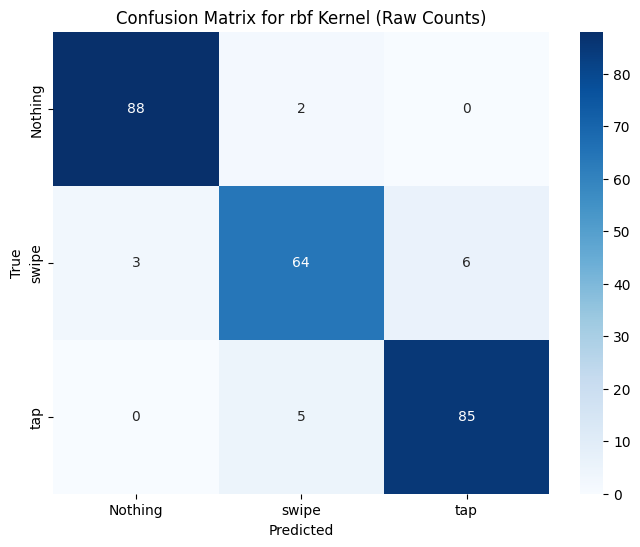

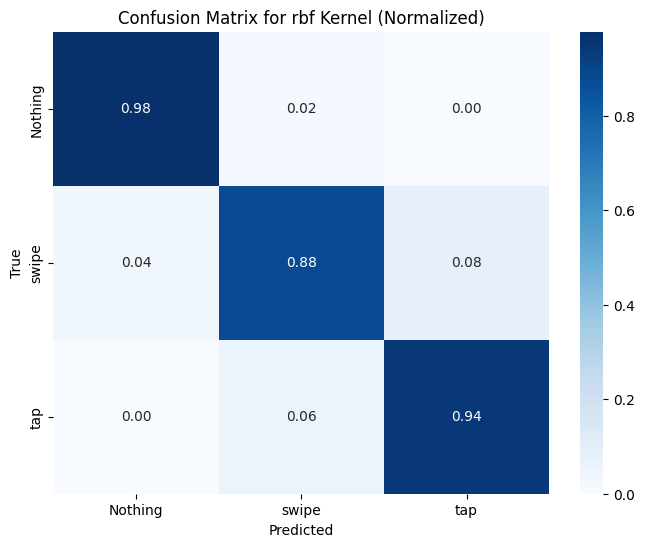

Cross-validation Mean Score for rbf kernel: 0.9317416963371213
Cross-validation Standard Deviation for rbf kernel: 0.014178757696800265


Kernel Comparison:
rbf kernel:
  Accuracy = 0.9367588932806324
  Mean CV Accuracy = 0.9317416963371213
  CV Standard Deviation = 0.014178757696800265



In [35]:
# from sklearn.model_selection import cross_val_score
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # List of kernels to try
# kernels = ['rbf']

# # Initialize dictionary to store results for each kernel
# kernel_results = {}

# for kernel in kernels:
#     print(f"Training SVM with {kernel} kernel...")
    
#     # Create and train an SVM model with the current kernel
#     svm_model = SVC(kernel=kernel, class_weight='balanced')
    
#     # Scale features
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     # Train the model on the scaled data
#     svm_model.fit(X_train_scaled, y_train)

#     # Predict on the test set
#     y_pred = svm_model.predict(X_test_scaled)

#     # Evaluate the model on the test set
#     accuracy = accuracy_score(y_test, y_pred)
#     print(f"Accuracy for {kernel} kernel: {accuracy}")
    
#     # Cross-validation
#     cross_val_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
#     mean_cv_score = cross_val_scores.mean()
#     std_cv_score = cross_val_scores.std()

#     # Store the result
#     kernel_results[kernel] = {
#         "accuracy": accuracy,
#         "mean_cv_score": mean_cv_score,
#         "std_cv_score": std_cv_score,
#         "cv_scores": cross_val_scores
#     }
    
#     # Print Classification Report
#     print(f"\nClassification Report for {kernel} kernel:")
#     print(classification_report(y_test, y_pred))

#     # Generate the confusion matrix
#     cm = confusion_matrix(y_test, y_pred)
    
#     # Normalize the confusion matrix
#     cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
#     # Class labels
#     class_labels = sorted(y_test.unique())

#     # Plot the confusion matrix (raw counts)
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.title(f'Confusion Matrix for {kernel} Kernel (Raw Counts)')
#     plt.show()

#     # Plot the normalized confusion matrix
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.title(f'Confusion Matrix for {kernel} Kernel (Normalized)')
#     plt.show()

#     # Print the cross-validation results
#     print(f"Cross-validation Mean Score for {kernel} kernel: {mean_cv_score}")
#     print(f"Cross-validation Standard Deviation for {kernel} kernel: {std_cv_score}\n")


# # Compare the accuracy and cross-validation results for each kernel
# print("\nKernel Comparison:")
# for kernel, results in kernel_results.items():
#     print(f"{kernel} kernel:")
#     print(f"  Accuracy = {results['accuracy']}")
#     print(f"  Mean CV Accuracy = {results['mean_cv_score']}")
#     print(f"  CV Standard Deviation = {results['std_cv_score']}\n")


# Unscaled

Training SVM with rbf kernel...
Accuracy for rbf kernel: 0.9335347432024169

Classification Report for rbf kernel:
              precision    recall  f1-score   support

     Nothing       0.90      1.00      0.95        64
        hold       0.93      0.86      0.89        90
       swipe       1.00      1.00      1.00        89
         tap       0.90      0.90      0.90        88

    accuracy                           0.93       331
   macro avg       0.93      0.94      0.93       331
weighted avg       0.93      0.93      0.93       331



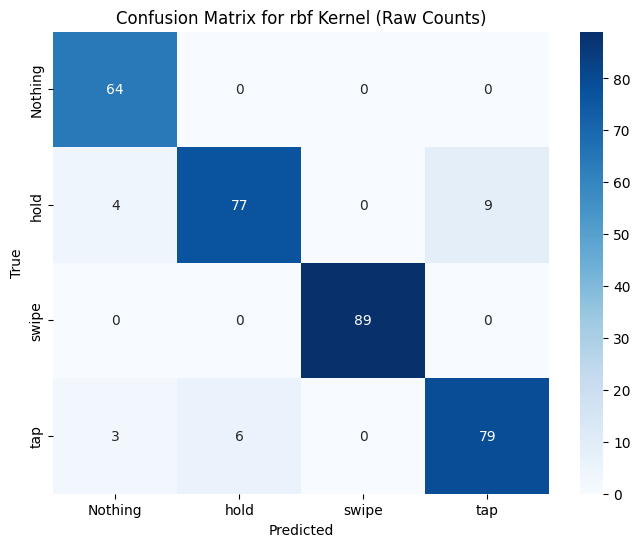

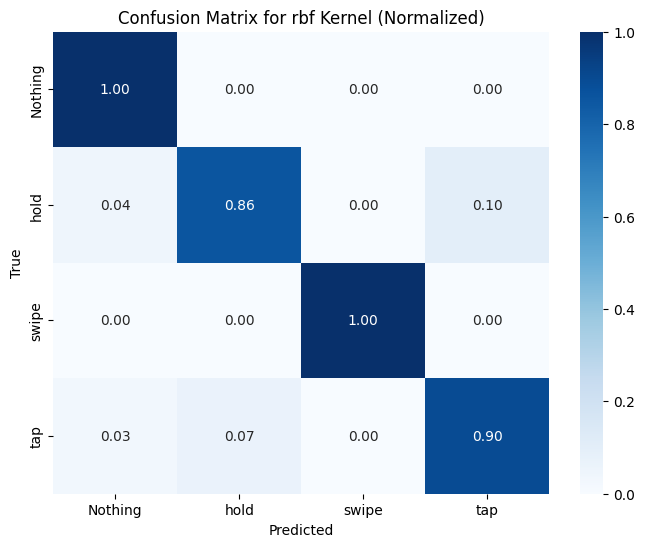

Cross-validation Mean Score for rbf kernel: 0.9092338479130933
Cross-validation Standard Deviation for rbf kernel: 0.02740971239676987


Kernel Comparison:
rbf kernel:
  Accuracy = 0.9335347432024169
  Mean CV Accuracy = 0.9092338479130933
  CV Standard Deviation = 0.02740971239676987



In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of kernels to try
kernels = ['rbf']

# Initialize dictionary to store results for each kernel
kernel_results = {}

for kernel in kernels:
    print(f"Training SVM with {kernel} kernel...")
    
    # Create and train an SVM model with the current kernel
    svm_model = SVC(kernel=kernel, class_weight='balanced')
    
    # Train the model on the raw data
    svm_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = svm_model.predict(X_test)

    # Evaluate the model on the test set
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {kernel} kernel: {accuracy}")
    
    # Cross-validation
    cross_val_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')
    mean_cv_score = cross_val_scores.mean()
    std_cv_score = cross_val_scores.std()

    # Store the result
    kernel_results[kernel] = {
        "accuracy": accuracy,
        "mean_cv_score": mean_cv_score,
        "std_cv_score": std_cv_score,
        "cv_scores": cross_val_scores
    }
    
    # Print Classification Report
    print(f"\nClassification Report for {kernel} kernel:")
    print(classification_report(y_test, y_pred))

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Class labels
    class_labels = sorted(y_test.unique())

    # Plot the confusion matrix (raw counts)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {kernel} Kernel (Raw Counts)')
    plt.show()

    # Plot the normalized confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {kernel} Kernel (Normalized)')
    plt.show()

    # Print the cross-validation results
    print(f"Cross-validation Mean Score for {kernel} kernel: {mean_cv_score}")
    print(f"Cross-validation Standard Deviation for {kernel} kernel: {std_cv_score}\n")


# Compare the accuracy and cross-validation results for each kernel
print("\nKernel Comparison:")
for kernel, results in kernel_results.items():
    print(f"{kernel} kernel:")
    print(f"  Accuracy = {results['accuracy']}")
    print(f"  Mean CV Accuracy = {results['mean_cv_score']}")
    print(f"  CV Standard Deviation = {results['std_cv_score']}\n")


# Here we can check the CV accuracy for each label individually

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

import numpy as np

In [77]:
# Initialize dictionary to store results for each kernel
kernel_results = {}

# List of kernels to try
kernels = ['rbf']

for kernel in kernels:
    print(f"Training SVM with {kernel} kernel...")
    
    # Create and train an SVM model with the current kernel
    svm_model = SVC(kernel=kernel, class_weight='balanced')
    
    
    # Train the model on the scaled data
    svm_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = svm_model.predict(X_test)

    # Evaluate the model on the test set
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {kernel} kernel: {accuracy}")
    
    # Cross-validation
    cross_val_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')
    mean_cv_score = cross_val_scores.mean()
    std_cv_score = cross_val_scores.std()

    # Initialize data structures for per-class CV accuracy
    unique_classes = np.unique(y_train)
    class_cv_accuracies = {cls: [] for cls in unique_classes}
    overall_cv_accuracies = []



    # Convert y_train to a NumPy array if it is a Series
    y_train_array = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train

    # Perform Stratified K-Fold Cross-Validation
    cv = StratifiedKFold(n_splits=5)
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train_array[train_idx], y_train_array[val_idx]


        # Train on fold
        svm_model.fit(X_fold_train, y_fold_train)

        # Validate on fold
        y_fold_pred = svm_model.predict(X_fold_val)

        # Compute metrics (accuracy, confusion matrix, etc.)
        # ...


        # Overall accuracy for fold
        fold_accuracy = accuracy_score(y_fold_val, y_fold_pred)
        overall_cv_accuracies.append(fold_accuracy)

        # Per-class accuracy for fold
        cm = confusion_matrix(y_fold_val, y_fold_pred, labels=unique_classes)
        fold_class_accuracies = cm.diagonal() / cm.sum(axis=1)
        for cls_idx, cls_acc in enumerate(fold_class_accuracies):
            if not np.isnan(cls_acc):  # Avoid division by zero for missing classes
                class_cv_accuracies[unique_classes[cls_idx]].append(cls_acc)

    # Compute final per-class CV accuracies
    mean_class_cv_accuracies = {
        cls: np.mean(accs) for cls, accs in class_cv_accuracies.items()
    }
    mean_overall_cv_accuracy = np.mean(overall_cv_accuracies)

    # Store the result
    kernel_results[kernel] = {
        "accuracy": accuracy,
        "mean_cv_score": mean_cv_score,
        "std_cv_score": std_cv_score,
        "cv_scores": cross_val_scores,
        "overall_cv_accuracy": mean_overall_cv_accuracy,
        "per_class_cv_accuracy": mean_class_cv_accuracies
    }
    
    print(f"Cross-validation Mean Score for {kernel} kernel: {mean_cv_score}")
    print(f"Cross-validation Standard Deviation for {kernel} kernel: {std_cv_score}")
    print(f"Per-Class CV Accuracies for {kernel} kernel: {mean_class_cv_accuracies}\n")


Training SVM with rbf kernel...
Accuracy for rbf kernel: 0.9196675900277008
Cross-validation Mean Score for rbf kernel: 0.9216262975778546
Cross-validation Standard Deviation for rbf kernel: 0.010039278513395072
Per-Class CV Accuracies for rbf kernel: {'Nothing': np.float64(1.0), 'hold': np.float64(0.8194444444444443), 'swipe': np.float64(0.960628844839371), 'tap': np.float64(0.9034100596760444)}



# Other algorithms  / Scaled

Training Random Forest...

Classification Report for Random Forest:
              precision    recall  f1-score   support

     Nothing       0.94      1.00      0.97        51
      stripe       0.91      0.84      0.88        51
       swipe       0.80      0.81      0.80        48
         tap       0.87      0.87      0.87        52

    accuracy                           0.88       202
   macro avg       0.88      0.88      0.88       202
weighted avg       0.88      0.88      0.88       202



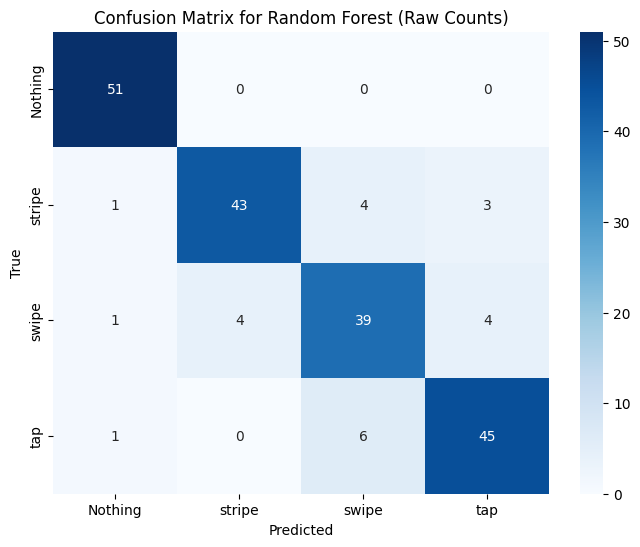

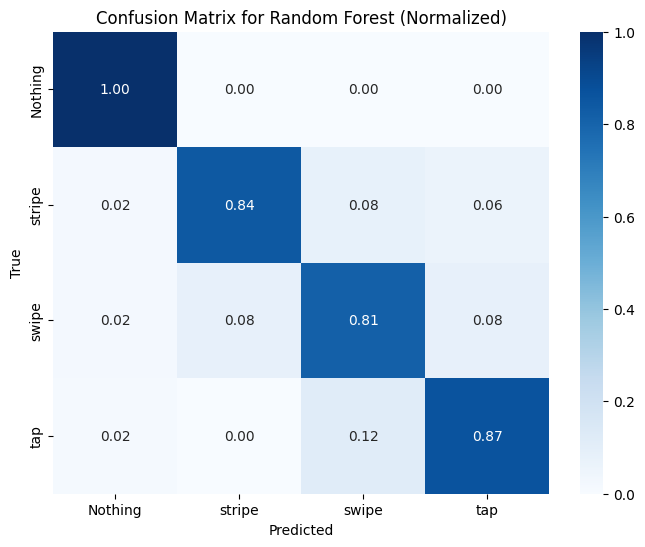

Cross-validation Mean Score for Random Forest: 0.904478184188329
Cross-validation Standard Deviation for Random Forest: 0.030538927803143778

Training Decision Tree...

Classification Report for Decision Tree:
              precision    recall  f1-score   support

     Nothing       0.94      0.94      0.94        51
      stripe       0.89      0.78      0.83        51
       swipe       0.79      0.77      0.78        48
         tap       0.81      0.92      0.86        52

    accuracy                           0.86       202
   macro avg       0.86      0.85      0.85       202
weighted avg       0.86      0.86      0.86       202



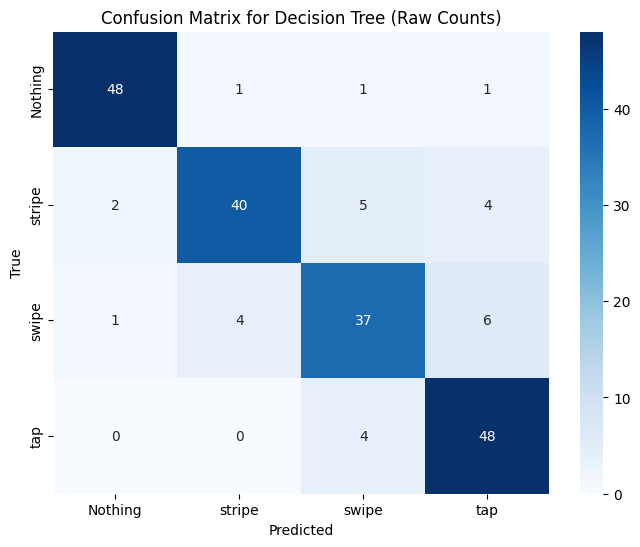

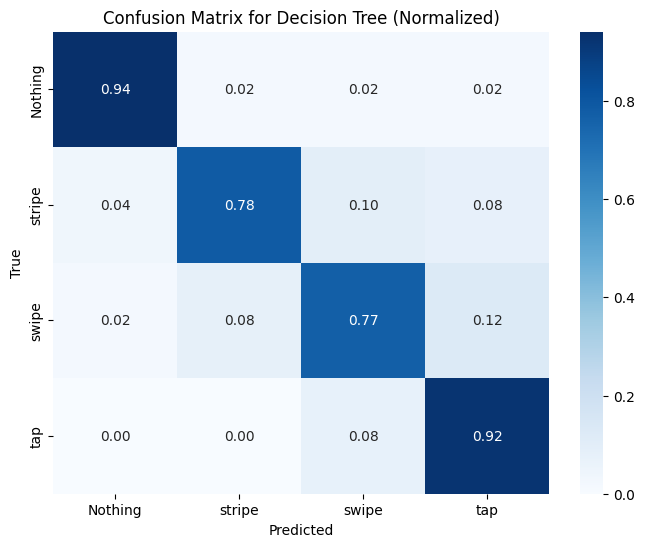

Cross-validation Mean Score for Decision Tree: 0.8250594279579786
Cross-validation Standard Deviation for Decision Tree: 0.023387882604560373

Training Gradient Boosting...

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

     Nothing       0.94      1.00      0.97        51
      stripe       0.90      0.86      0.88        51
       swipe       0.85      0.83      0.84        48
         tap       0.92      0.92      0.92        52

    accuracy                           0.91       202
   macro avg       0.90      0.90      0.90       202
weighted avg       0.91      0.91      0.91       202



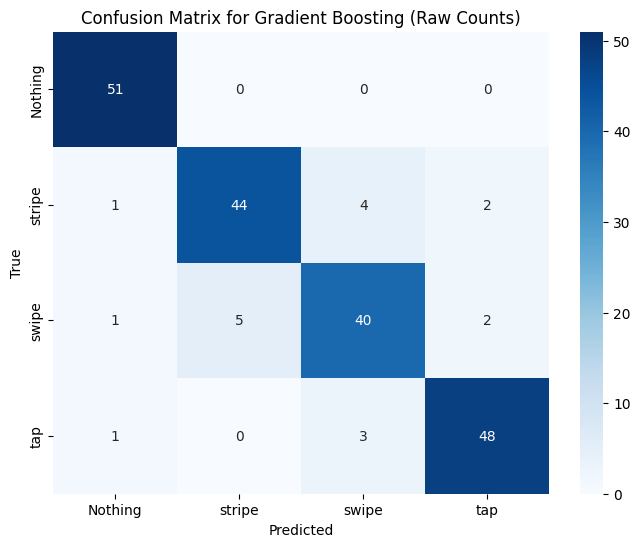

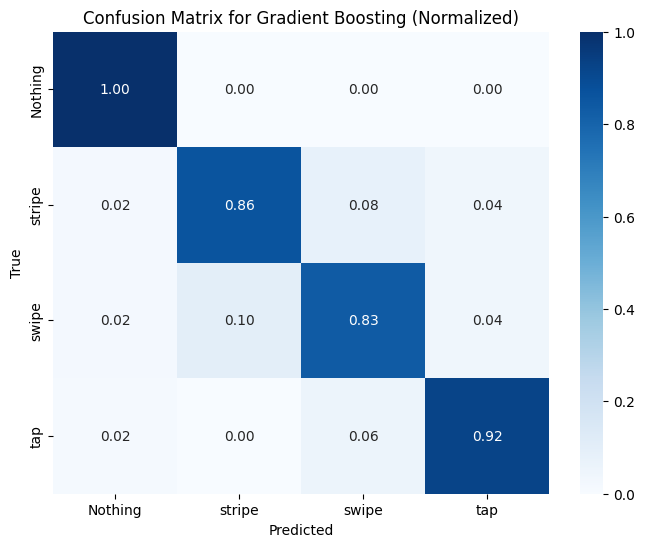

Cross-validation Mean Score for Gradient Boosting: 0.9069703243616287
Cross-validation Standard Deviation for Gradient Boosting: 0.016039573826179647


Model Comparison:
Random Forest:
  Accuracy = 0.8811881188118812
  Mean CV Accuracy = 0.904478184188329
  CV Standard Deviation = 0.030538927803143778

Decision Tree:
  Accuracy = 0.8564356435643564
  Mean CV Accuracy = 0.8250594279579786
  CV Standard Deviation = 0.023387882604560373

Gradient Boosting:
  Accuracy = 0.905940594059406
  Mean CV Accuracy = 0.9069703243616287
  CV Standard Deviation = 0.016039573826179647



In [40]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.model_selection import cross_val_score
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Initialize classifiers
# models = {
#     # "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
#     "Random Forest": RandomForestClassifier(class_weight='balanced'),
#     # "K-Nearest Neighbors": KNeighborsClassifier(),
#     "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
#     # "Naive Bayes": GaussianNB(),
#     "Gradient Boosting": GradientBoostingClassifier()
# }

# # Dictionary to store results
# model_results = {}

# # Loop over each model and evaluate its performance
# for model_name, model in models.items():
#     print(f"Training {model_name}...")

#     # Train the model on scaled data
#     model.fit(X_train_scaled, y_train)

#     # Predict on the test set
#     y_pred = model.predict(X_test_scaled)

#     # Evaluate the model on test set
#     accuracy = accuracy_score(y_test, y_pred)
    
#     # Cross-validation
#     cross_val_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
#     mean_cv_score = cross_val_scores.mean()
#     std_cv_score = cross_val_scores.std()

#     # Store results in the model_results dictionary
#     model_results[model_name] = {
#         "accuracy": accuracy,
#         "mean_cv_score": mean_cv_score,
#         "std_cv_score": std_cv_score,
#         "cv_scores": cross_val_scores
#     }

#     # Print Classification Report
#     print(f"\nClassification Report for {model_name}:")
#     print(classification_report(y_test, y_pred))

#     # Generate the confusion matrix
#     cm = confusion_matrix(y_test, y_pred)

#     # Normalize the confusion matrix
#     cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
#     # Class labels
#     class_labels = sorted(y_test.unique())

#     # Plot the confusion matrix (raw counts)
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.title(f'Confusion Matrix for {model_name} (Raw Counts)')
#     plt.show()

#     # Plot the normalized confusion matrix
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.title(f'Confusion Matrix for {model_name} (Normalized)')
#     plt.show()

#     # Print the cross-validation results
#     print(f"Cross-validation Mean Score for {model_name}: {mean_cv_score}")
#     print(f"Cross-validation Standard Deviation for {model_name}: {std_cv_score}\n")

# # Compare the accuracy and cross-validation results for each model
# print("\nModel Comparison:")
# for model_name, results in model_results.items():
#     print(f"{model_name}:")
#     print(f"  Accuracy = {results['accuracy']}")
#     print(f"  Mean CV Accuracy = {results['mean_cv_score']}")
#     print(f"  CV Standard Deviation = {results['std_cv_score']}\n")


In [56]:
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import GaussianNB
# import numpy as np
# import pandas as pd

# # Algorithms to evaluate
# algorithms = {

#     "Random Forest": RandomForestClassifier(class_weight='balanced'),
#     "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
#     "Gradient Boosting": GradientBoostingClassifier(),
# }

# # Initialize dictionary to store results
# algorithm_results = {}

# # Scale features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# for algorithm_name, model in algorithms.items():
#     print(f"Training and evaluating: {algorithm_name}...")
    
#     # Train the model
#     model.fit(X_train_scaled, y_train)
#     y_pred = model.predict(X_test_scaled)

#     # Evaluate on test set
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"Test Accuracy: {test_accuracy}")

#     # Cross-validation setup
#     unique_classes = np.unique(y_train)
#     class_cv_accuracies = {cls: [] for cls in unique_classes}
#     overall_cv_accuracies = []

#     # Convert y_train to a NumPy array if it is a Series
#     y_train_array = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train

#     cv = StratifiedKFold(n_splits=5)
#     for train_idx, val_idx in cv.split(X_train, y_train):
#         X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
#         y_fold_train, y_fold_val = y_train_array[train_idx], y_train_array[val_idx]

#         # Train and validate on fold
#         model.fit(X_fold_train, y_fold_train)
#         y_fold_pred = model.predict(X_fold_val)

#         # Overall accuracy for fold
#         fold_accuracy = accuracy_score(y_fold_val, y_fold_pred)
#         overall_cv_accuracies.append(fold_accuracy)

#         # Per-class accuracy for fold
#         cm = confusion_matrix(y_fold_val, y_fold_pred, labels=unique_classes)
#         fold_class_accuracies = cm.diagonal() / cm.sum(axis=1)
#         for cls_idx, cls_acc in enumerate(fold_class_accuracies):
#             if not np.isnan(cls_acc):  # Avoid division by zero for missing classes
#                 class_cv_accuracies[unique_classes[cls_idx]].append(cls_acc)

#     # Compute final per-class CV accuracies
#     mean_class_cv_accuracies = {
#         cls: np.mean(accs) for cls, accs in class_cv_accuracies.items()
#     }
#     mean_overall_cv_accuracy = np.mean(overall_cv_accuracies)

#     # Store results
#     algorithm_results[algorithm_name] = {
#         "test_accuracy": test_accuracy,
#         "overall_cv_accuracy": mean_overall_cv_accuracy,
#         "per_class_cv_accuracy": mean_class_cv_accuracies,
#     }

#     print(f"Cross-Validation Mean Overall Accuracy: {mean_overall_cv_accuracy}")
#     print(f"Per-Class CV Accuracies: {mean_class_cv_accuracies}\n")

# # # Print overall results for all algorithms
# # print("\nSummary of Results:")
# # for algorithm_name, results in algorithm_results.items():
# #     print(f"{algorithm_name}:")
# #     print(f"  Test Accuracy: {results['test_accuracy']}")
# #     print(f"  Cross-Validation Mean Overall Accuracy: {results['overall_cv_accuracy']}")
# #     print(f"  Per-Class CV Accuracies: {results['per_class_cv_accuracy']}\n")


Training and evaluating: Random Forest...
Test Accuracy: 1.0
Cross-Validation Mean Overall Accuracy: 0.9909205260148657
Per-Class CV Accuracies: {'Nothing': np.float64(0.996078431372549), 'hold': np.float64(0.9777777777777779), 'swipe': np.float64(1.0), 'tap': np.float64(0.9915090543259557)}

Training and evaluating: Decision Tree...
Test Accuracy: 0.9939577039274925
Cross-Validation Mean Overall Accuracy: 0.9659719839908518
Per-Class CV Accuracies: {'Nothing': np.float64(0.9921568627450981), 'hold': np.float64(0.9333333333333333), 'swipe': np.float64(0.9971830985915492), 'tap': np.float64(0.9490140845070423)}

Training and evaluating: Gradient Boosting...
Test Accuracy: 0.9969788519637462
Cross-Validation Mean Overall Accuracy: 0.9825929102344195
Per-Class CV Accuracies: {'Nothing': np.float64(0.9921568627450981), 'hold': np.float64(0.9638888888888889), 'swipe': np.float64(0.9971830985915492), 'tap': np.float64(0.9801207243460764)}



# Other algorithms unscaled

Training Random Forest...

Classification Report for Random Forest:
              precision    recall  f1-score   support

     Nothing       1.00      1.00      1.00        90
        hold       0.99      0.98      0.98        90
       swipe       0.99      0.98      0.98        96
         tap       0.98      1.00      0.99        85

    accuracy                           0.99       361
   macro avg       0.99      0.99      0.99       361
weighted avg       0.99      0.99      0.99       361



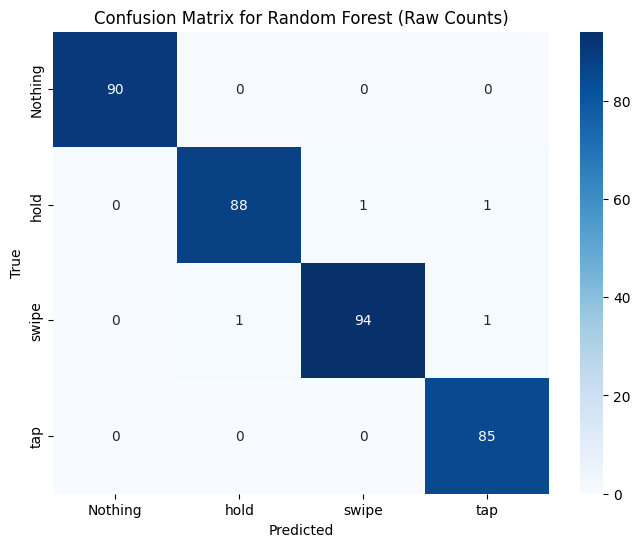

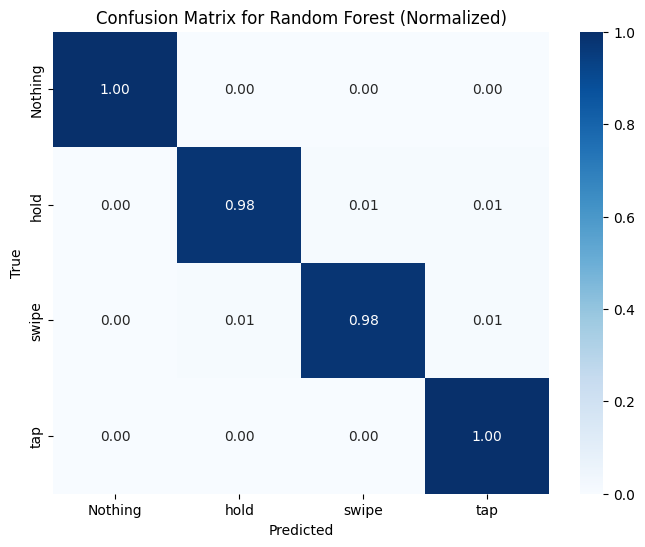

Cross-validation Mean Score for Random Forest: 0.9889009034986543
Cross-validation Standard Deviation for Random Forest: 0.007085521351533267

Training Decision Tree...

Classification Report for Decision Tree:
              precision    recall  f1-score   support

     Nothing       1.00      1.00      1.00        90
        hold       0.92      0.88      0.90        90
       swipe       0.92      0.95      0.93        96
         tap       0.93      0.94      0.94        85

    accuracy                           0.94       361
   macro avg       0.94      0.94      0.94       361
weighted avg       0.94      0.94      0.94       361



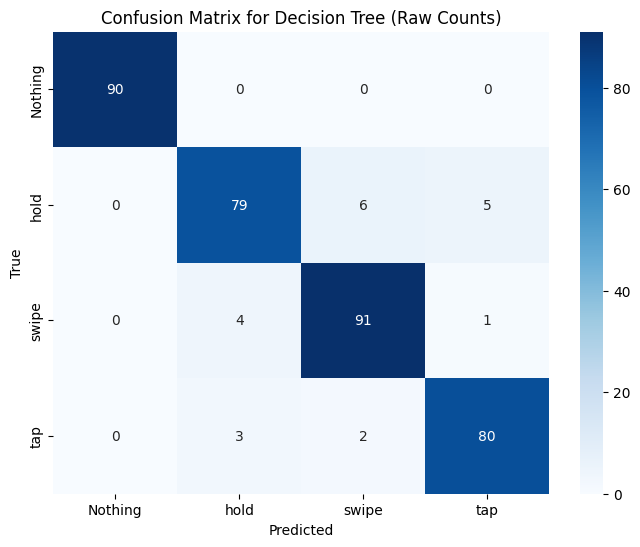

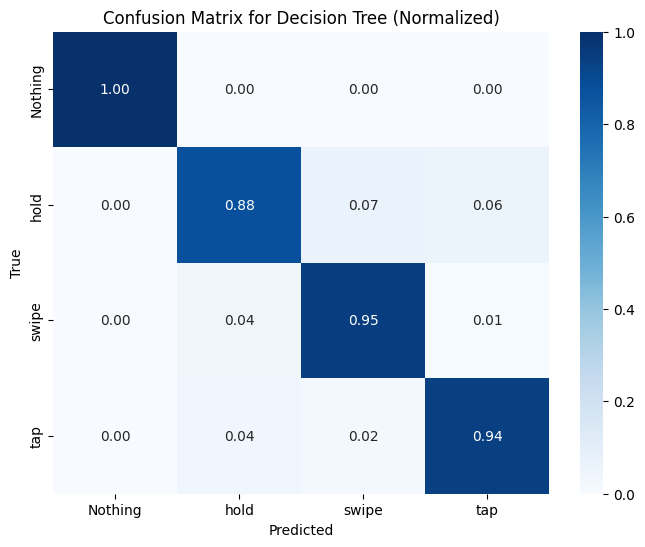

Cross-validation Mean Score for Decision Tree: 0.9445237408688966
Cross-validation Standard Deviation for Decision Tree: 0.010949394756340505

Training Gradient Boosting...

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

     Nothing       1.00      1.00      1.00        90
        hold       1.00      0.98      0.99        90
       swipe       0.98      1.00      0.99        96
         tap       1.00      1.00      1.00        85

    accuracy                           0.99       361
   macro avg       0.99      0.99      0.99       361
weighted avg       0.99      0.99      0.99       361



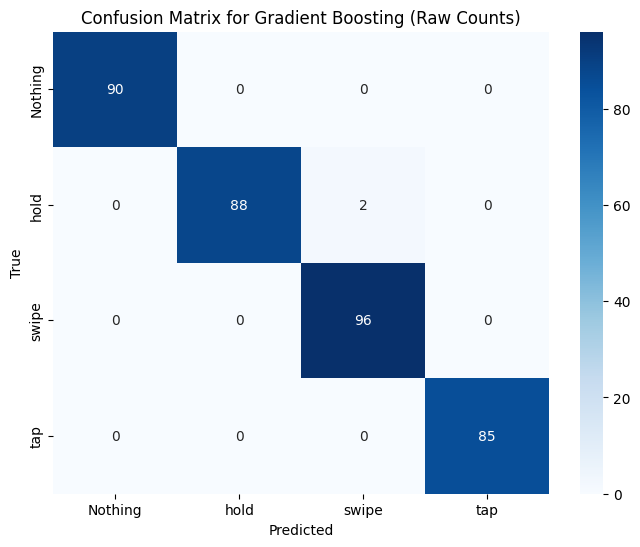

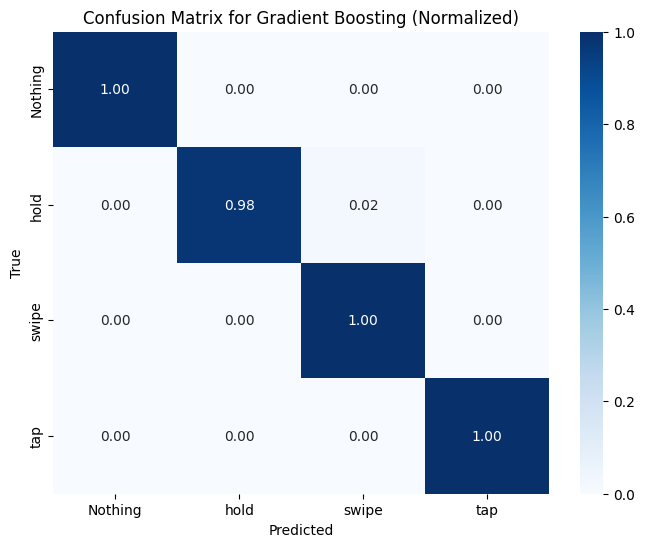

Cross-validation Mean Score for Gradient Boosting: 0.9875216262975778
Cross-validation Standard Deviation for Gradient Boosting: 0.007135082546858276


Model Comparison:
Random Forest:
  Accuracy = 0.9889196675900277
  Mean CV Accuracy = 0.9889009034986543
  CV Standard Deviation = 0.007085521351533267

Decision Tree:
  Accuracy = 0.9418282548476454
  Mean CV Accuracy = 0.9445237408688966
  CV Standard Deviation = 0.010949394756340505

Gradient Boosting:
  Accuracy = 0.9944598337950139
  Mean CV Accuracy = 0.9875216262975778
  CV Standard Deviation = 0.007135082546858276



In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize classifiers
models = {

    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    # "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    # "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Dictionary to store results
model_results = {}

# Loop over each model and evaluate its performance
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train the model on scaled data
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model on test set
    accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validation
    cross_val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_cv_score = cross_val_scores.mean()
    std_cv_score = cross_val_scores.std()

    # Store results in the model_results dictionary
    model_results[model_name] = {
        "accuracy": accuracy,
        "mean_cv_score": mean_cv_score,
        "std_cv_score": std_cv_score,
        "cv_scores": cross_val_scores
    }

    # Print Classification Report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Class labels
    class_labels = sorted(y_test.unique())

    # Plot the confusion matrix (raw counts)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {model_name} (Raw Counts)')
    plt.show()

    # Plot the normalized confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {model_name} (Normalized)')
    plt.show()

    # Print the cross-validation results
    print(f"Cross-validation Mean Score for {model_name}: {mean_cv_score}")
    print(f"Cross-validation Standard Deviation for {model_name}: {std_cv_score}\n")

# Compare the accuracy and cross-validation results for each model
print("\nModel Comparison:")
for model_name, results in model_results.items():
    print(f"{model_name}:")
    print(f"  Accuracy = {results['accuracy']}")
    print(f"  Mean CV Accuracy = {results['mean_cv_score']}")
    print(f"  CV Standard Deviation = {results['std_cv_score']}\n")


In [78]:
algorithms = {

    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
}

# Initialize dictionary to store results
algorithm_results = {}

for algorithm_name, model in algorithms.items():
    print(f"Training and evaluating: {algorithm_name}...")
    
    # Train the model without scaling
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate on test set
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {test_accuracy}")

    # Cross-validation setup
    unique_classes = np.unique(y_train)
    class_cv_accuracies = {cls: [] for cls in unique_classes}
    overall_cv_accuracies = []

    # Convert y_train to a NumPy array if it is a Series
    y_train_array = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train

    cv = StratifiedKFold(n_splits=5)
    for train_idx, val_idx in cv.split(X_train, y_train):
        # Use .iloc[] to index rows properly
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]  # No scaling
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Train and validate on fold
        model.fit(X_fold_train, y_fold_train)
        y_fold_pred = model.predict(X_fold_val)

        # Overall accuracy for fold
        fold_accuracy = accuracy_score(y_fold_val, y_fold_pred)
        overall_cv_accuracies.append(fold_accuracy)

        # Per-class accuracy for fold
        cm = confusion_matrix(y_fold_val, y_fold_pred, labels=unique_classes)
        fold_class_accuracies = cm.diagonal() / cm.sum(axis=1)
        for cls_idx, cls_acc in enumerate(fold_class_accuracies):
            if not np.isnan(cls_acc):  # Avoid division by zero for missing classes
                class_cv_accuracies[unique_classes[cls_idx]].append(cls_acc)

    # Compute final per-class CV accuracies
    mean_class_cv_accuracies = {
        cls: np.mean(accs) for cls, accs in class_cv_accuracies.items()
    }
    mean_overall_cv_accuracy = np.mean(overall_cv_accuracies)

    # Store results
    algorithm_results[algorithm_name] = {
        "test_accuracy": test_accuracy,
        "overall_cv_accuracy": mean_overall_cv_accuracy,
        "per_class_cv_accuracy": mean_class_cv_accuracies,
    }

    print(f"Cross-Validation Mean Overall Accuracy: {mean_overall_cv_accuracy}")
    print(f"Per-Class CV Accuracies: {mean_class_cv_accuracies}\n")


Training and evaluating: Random Forest...
Test Accuracy: 0.9944598337950139
Cross-Validation Mean Overall Accuracy: 0.985426278354479
Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'hold': np.float64(0.9805555555555557), 'swipe': np.float64(0.9815789473684211), 'tap': np.float64(0.9795822676896846)}

Training and evaluating: Decision Tree...
Test Accuracy: 0.9695290858725761
Cross-Validation Mean Overall Accuracy: 0.9472750865051903
Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'hold': np.float64(0.913888888888889), 'swipe': np.float64(0.9579972658920027), 'tap': np.float64(0.9152173913043479)}

Training and evaluating: Gradient Boosting...
Test Accuracy: 0.997229916897507
Cross-Validation Mean Overall Accuracy: 0.9861231257208765
Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'hold': np.float64(0.9722222222222223), 'swipe': np.float64(0.9868762816131238), 'tap': np.float64(0.9854219948849104)}



# To save the models here

Do not forget to change the naming convention when needed

# unscaled/save

In [79]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Initialize models
models = {
    #"Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    # "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    # "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    #"SVM (Linear Kernel)": SVC(kernel='linear', class_weight='balanced'),
    #"SVM (Polynomial Kernel)": SVC(kernel='poly', class_weight='balanced'),
    "SVM (RBF Kernel)": SVC(kernel='rbf', class_weight='balanced'),
   # "SVM (Sigmoid Kernel)": SVC(kernel='sigmoid', class_weight='balanced'),
}



# Train and save models
model_files = {}


for name, model in models.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)



    # CHANGE THE NAME HERE

    # # Save the trained model with "tribopression" prefix
    filename = f"tribo_differential_15april_LA_{name.replace(' ', '_').lower()}_model.pkl"





    with open(filename, 'wb') as file:
        pickle.dump(model, file)
    model_files[name] = filename
    print(f"{name} saved to {filename}.")

# Confirm saved files
print("\nModels saved:")
for name, filename in model_files.items():
    print(f"{name}: {filename}")


Training Random Forest...
Random Forest saved to tribo_differential_18Feb_LA_random_forest_model.pkl.
Training Decision Tree...
Decision Tree saved to tribo_differential_18Feb_LA_decision_tree_model.pkl.
Training Gradient Boosting...
Gradient Boosting saved to tribo_differential_18Feb_LA_gradient_boosting_model.pkl.
Training SVM (RBF Kernel)...
SVM (RBF Kernel) saved to tribo_differential_18Feb_LA_svm_(rbf_kernel)_model.pkl.

Models saved:
Random Forest: tribo_differential_18Feb_LA_random_forest_model.pkl
Decision Tree: tribo_differential_18Feb_LA_decision_tree_model.pkl
Gradient Boosting: tribo_differential_18Feb_LA_gradient_boosting_model.pkl
SVM (RBF Kernel): tribo_differential_18Feb_LA_svm_(rbf_kernel)_model.pkl


# When Done, I repeat the same process for the other sensor

In [ ]:
# RA
# Training and evaluating: Random Forest...
# Test Accuracy: 1.0
# Cross-Validation Mean Overall Accuracy: 0.9924385363064608
# Per-Class CV Accuracies: {'Nothing': np.float64(0.996078431372549), 'hold': np.float64(0.9833333333333334), 'swipe': np.float64(1.0), 'tap': np.float64(0.991549295774648)}

# Training and evaluating: Decision Tree...
# Test Accuracy: 0.9939577039274925
# Cross-Validation Mean Overall Accuracy: 0.9674814179531162
# Per-Class CV Accuracies: {'Nothing': np.float64(0.9883107088989442), 'hold': np.float64(0.9361111111111112), 'swipe': np.float64(1.0), 'tap': np.float64(0.9517907444668008)}

# Training and evaluating: Gradient Boosting...
# Test Accuracy: 0.9969788519637462
# Cross-Validation Mean Overall Accuracy: 0.9825929102344195
# Per-Class CV Accuracies: {'Nothing': np.float64(0.9921568627450981), 'hold': np.float64(0.9638888888888889), 'swipe': np.float64(0.9971830985915492), 'tap': np.float64(0.9801207243460764)}


# LA
# Training and evaluating: Random Forest...
# Test Accuracy: 0.9971910112359551
# Cross-Validation Mean Overall Accuracy: 0.9866197183098592
# Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'hold': np.float64(0.9833333333333334), 'swipe': np.float64(0.975), 'tap': np.float64(0.9883631713554987)}

# Training and evaluating: Decision Tree...
# Test Accuracy: 0.9775280898876404
# Cross-Validation Mean Overall Accuracy: 0.9549295774647888
# Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'hold': np.float64(0.9361111111111111), 'swipe': np.float64(0.9527777777777777), 'tap': np.float64(0.929624893435635)}

# Training and evaluating: Gradient Boosting...
# Test Accuracy: 0.9859550561797753
# Cross-Validation Mean Overall Accuracy: 0.9866197183098592
# Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'hold': np.float64(0.9805555555555555), 'swipe': np.float64(0.975), 'tap': np.float64(0.9913043478260869)}

# BA 
# Training and evaluating: Random Forest...
# Test Accuracy: 1.0
# Cross-Validation Mean Overall Accuracy: 0.9971473707966598
# Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'swipe': np.float64(0.9916666666666668), 'tap': np.float64(1.0)}

# Training and evaluating: Decision Tree...
# Test Accuracy: 1.0
# Cross-Validation Mean Overall Accuracy: 0.9952471225457007
# Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'swipe': np.float64(0.9916666666666668), 'tap': np.float64(0.9939393939393939)}

# Training and evaluating: Gradient Boosting...
# Test Accuracy: 1.0
# Cross-Validation Mean Overall Accuracy: 0.9961949898442789
# Per-Class CV Accuracies: {'Nothing': np.float64(1.0), 'swipe': np.float64(0.9944444444444445), 'tap': np.float64(0.9939393939393939)}



# Signal Correlation

Correlation with flat: 0.0036628989343969673
Correlation with triangle: -0.02040498162975845


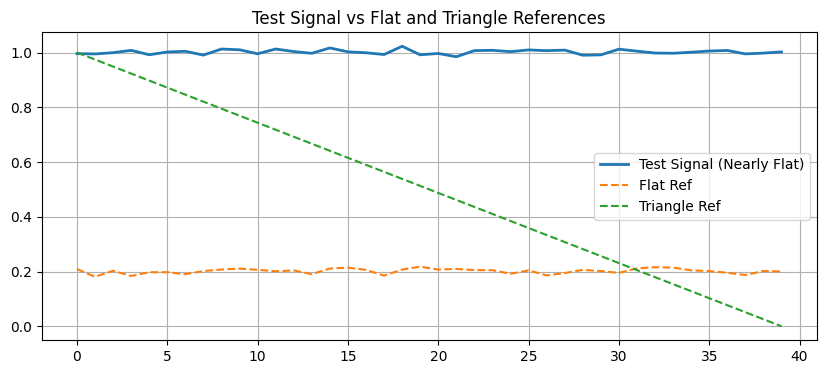

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Create reference patterns
ref_flat = np.full(40, 0.2) 
#+ np.random.normal(0, 0.01, 40)  # Almost flat
ref_triangle = np.linspace(1, 0, 40)  # Triangle pattern


# # --- Reference signals ---
# ref_flat = np.full(40, 0.05)  # or 0.0 if you want a completely flat zero line
# # ref_flat = np.ones(40)


# --- Dummy test signal ---
# Example: similar to triangle with a bit of noise
# test_signal = ref_triangle + np.random.normal(0, 0.3, 40)


# --- Simulate a nearly flat signal (noise around 0.05) ---
test_signal = np.full(40, 0.05) + np.random.normal(0, 0.01, 40)



# Simulate a nearly flat test signal
test_signal = np.full(40, 1) + np.random.normal(0, 0.01, 40)

# Calculate correlations
corr_flat, _ = pearsonr(test_signal, ref_flat)
corr_triangle, _ = pearsonr(test_signal, ref_triangle)

print("Correlation with flat:", corr_flat)
print("Correlation with triangle:", corr_triangle)

# Plot
x = np.arange(40)
plt.figure(figsize=(10, 4))
plt.plot(x, test_signal, label='Test Signal (Nearly Flat)', linewidth=2)
plt.plot(x, ref_flat, '--', label='Flat Ref')
plt.plot(x, ref_triangle, '--', label='Triangle Ref')
plt.legend()
plt.title("Test Signal vs Flat and Triangle References")
plt.grid(True)
plt.show()


Flat correlation: 0.11849949575093824
Triangle correlation: -0.22539444764172328


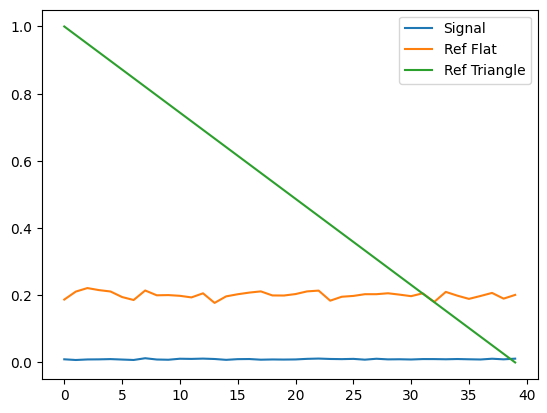

In [30]:
from scipy.stats import pearsonr
import numpy as np

# Create references
ref_flat = np.full(40, 0.2) + np.random.normal(0, 0.01, 40)  # Almost flat
ref_triangle = np.linspace(1, 0, 40)

# Example test: nearly flat signal with small noise
signal = np.random.normal(0.01, 0.001, 40)

# Demean to focus only on shape, not mean offset
signal_demeaned = signal - np.mean(signal)
flat_demeaned = ref_flat - np.mean(ref_flat)
triangle_demeaned = ref_triangle - np.mean(ref_triangle)

# Pearson correlation
corr_flat, _ = pearsonr(signal_demeaned, flat_demeaned)
corr_triangle, _ = pearsonr(signal_demeaned, triangle_demeaned)

print(f"Flat correlation: {corr_flat}")
print(f"Triangle correlation: {corr_triangle}")


import matplotlib.pyplot as plt

plt.plot(signal, label="Signal")
plt.plot(ref_flat, label="Ref Flat")
plt.plot(ref_triangle, label="Ref Triangle")
plt.legend()
plt.show()
